# Repeated IQM Shot Evaluation

This notebook is based on `all_folds_evaluation.ipynb`, but it focuses on repeated IQM hardware runs for three fixed schedules:

- `100 x 50 shots`
- `10 x 500 shots`
- `1 x 5000 shots`

For each schedule it:

- runs the selected fold(s) repeatedly on IQM,
- saves `accuracy` and `f1` for every single run,
- saves fold-level details for every run,
- builds two bar charts with the mean accuracy and mean F1 across runs.

The outputs are saved under `evaluation_and_comparison/repeated_shot_outputs/`.

In [1]:
import json
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from qiskit import QuantumCircuit, transpile
from qiskit.circuit import ParameterVector
from qiskit.primitives import PrimitiveResult, PubResult, StatevectorEstimator
from qiskit.primitives.base import BaseEstimatorV2
from qiskit.primitives.containers.data_bin import DataBin
from qiskit.quantum_info import SparsePauliOp
from qiskit_algorithms.gradients import ReverseEstimatorGradient
from qiskit_machine_learning.connectors import TorchConnector
from qiskit_machine_learning.neural_networks import EstimatorQNN
from sklearn.metrics import accuracy_score, f1_score

try:
    from tqdm import tqdm
    HAS_TQDM = True
except ImportError:
    HAS_TQDM = False
    print("tqdm not available; falling back to plain progress output.")


def ansatz(n_qubits, depth):
    params_per_iter = 4 * n_qubits
    theta = ParameterVector('θ', params_per_iter * (depth // 2))

    qc = QuantumCircuit(n_qubits)
    for j in range(depth // 2):
        offset = j * params_per_iter

        for i in range(n_qubits):
            qc.ry(theta[offset + i], i)

        for i in range(n_qubits):
            control = i
            target = (i + 1) % n_qubits
            param_idx = offset + n_qubits + i
            qc.rz(theta[param_idx], target)
            qc.cz(control, target)

        offset_l2 = offset + 2 * n_qubits

        for i in range(n_qubits):
            qc.rx(theta[offset_l2 + i], i)

        for i in range(n_qubits):
            control = i
            target = (i - 1) % n_qubits
            param_idx = offset_l2 + n_qubits + i
            qc.ry(theta[param_idx], target)
            qc.cz(control, target)

    return qc


class SimpleIQMJob:
    def __init__(self, result):
        self._result = result

    def result(self):
        return self._result


class IQMBackendEstimator(BaseEstimatorV2):
    def __init__(self, backend, options=None):
        super().__init__()
        self._backend = backend
        self._options = options or {"shots": 100}
        self.timestamp_history = []
        self.total_qpu_time = 0.0

    def _extract_timestamps(self, result):
        try:
            timeline = result._metadata.get('timeline', [])
            if not timeline:
                return None

            timestamps = {}
            for entry in timeline:
                timestamps[entry.status] = entry.timestamp
            return timestamps
        except Exception:
            return None

    def _counts_to_expectation(self, counts):
        if isinstance(counts, list):
            counts = counts[0]
        shots = sum(counts.values())
        count_0 = sum(c for bitstring, c in counts.items() if bitstring[-1] == '0')
        p0 = count_0 / shots if shots else 0.0
        return p0 - (1 - p0)

    def run(self, pubs, precision=None):
        if not isinstance(pubs, list):
            pubs = [pubs]

        job_results = []
        shots_opt = self._options["shots"]
        max_circuits = self._options.get("max_circuits_per_job")

        base_circuit = pubs[0][0]
        circuit_with_meas = base_circuit.copy()
        if circuit_with_meas.num_clbits == 0:
            circuit_with_meas.measure_all()
        transpiled_qc = transpile(circuit_with_meas, self._backend, optimization_level=3)

        for pub in pubs:
            _, observables, parameter_values = pub
            if parameter_values.ndim == 1:
                parameter_values = [parameter_values]

            bound_circuits = [transpiled_qc.assign_parameters(params) for params in parameter_values]
            n_circuits = len(bound_circuits)
            pub_expectations = []

            for start in range(0, n_circuits, max_circuits or n_circuits):
                end = min(start + (max_circuits or n_circuits), n_circuits)
                batch = bound_circuits[start:end]
                try:
                    job = self._backend.run(batch, shots=shots_opt)
                    result = job.result()

                    ts = self._extract_timestamps(result)
                    if ts:
                        exec_start = ts.get('execution_started')
                        exec_end = ts.get('execution_ended')
                        comp_start = ts.get('compilation_started')
                        comp_end = ts.get('compilation_ended')
                        job_created = ts.get('created')
                        job_completed = ts.get('completed')
                        if exec_start and exec_end:
                            execution_time = (exec_end - exec_start).total_seconds()
                            compile_time = (comp_end - comp_start).total_seconds() if comp_start and comp_end else 0.0
                            job_time = (job_completed - job_created).total_seconds() if job_created and job_completed else 0.0
                            self.timestamp_history.append({
                                'execution_time_qpu': execution_time,
                                'job_time_total': job_time,
                                'compile_time': compile_time,
                                'raw_timestamps': ts,
                                'n_circuits': len(batch),
                            })
                            self.total_qpu_time += execution_time

                    counts_list = result.get_counts()
                    if not isinstance(counts_list, list):
                        counts_list = [counts_list]
                    for counts in counts_list:
                        pub_expectations.append(self._counts_to_expectation(counts))
                except Exception as exc:
                    print(f"Batch job failed: {exc}")
                    pub_expectations.extend([0.0] * len(batch))

            data = DataBin(evs=np.array(pub_expectations), shape=(len(pub_expectations),))
            job_results.append(PubResult(data=data))

        return SimpleIQMJob(PrimitiveResult(job_results))


RANDOM_SEED = 42


class HybridModel(nn.Module):
    def __init__(self, ansatz_circuit, num_qubits):
        super().__init__()
        self.feature_map = self.angle_encoding(num_qubits)

        self.qc = QuantumCircuit(num_qubits)
        self.qc.compose(self.feature_map, qubits=range(num_qubits), inplace=True)
        self.qc.compose(ansatz_circuit, inplace=True)

        input_params = list(self.feature_map.parameters)
        weight_params = list(ansatz_circuit.parameters)
        observable = SparsePauliOp.from_list([("I" * (num_qubits - 1) + "Z", 1)])
        estimator = StatevectorEstimator(seed=RANDOM_SEED)
        gradient = ReverseEstimatorGradient(estimator)

        self.qnn = EstimatorQNN(
            circuit=self.qc,
            observables=observable,
            input_params=input_params,
            weight_params=weight_params,
            estimator=estimator,
            gradient=gradient,
        )
        self.quantum_layer = TorchConnector(self.qnn)

    def angle_encoding(self, num_qubits):
        qc_data = QuantumCircuit(num_qubits)
        input_params = ParameterVector('x', num_qubits)
        for i in range(num_qubits):
            qc_data.ry(input_params[i], i)
        return qc_data

    def forward(self, x):
        return self.quantum_layer(x)


NUM_QUBITS = 5
ANSATZ_DEPTH = 2
DEFAULT_SOURCE = "noise"
DEFAULT_CHECKPOINT = "final"
OUTPUT_ROOT = Path("evaluation_and_comparison") / "repeated_shot_outputs"
EXPERIMENT_SPECS = [
    {"label": "100 x 50 shots", "shots": 50, "repeats": 100},
    {"label": "10 x 500 shots", "shots": 500, "repeats": 10},
    {"label": "1 x 5000 shots", "shots": 5000, "repeats": 1},
]


def _project_root():
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / "cross_validation").exists():
            return candidate
    raise FileNotFoundError("Could not locate the project root containing cross_validation/.")


def available_folds():
    root = _project_root() / "cross_validation" / f"depth_{ANSATZ_DEPTH}"
    folds = []
    for path in sorted(root.glob("fold_*")):
        if path.is_dir():
            try:
                folds.append(int(path.name.split("_")[1]))
            except (IndexError, ValueError):
                pass
    return folds


def _fold_dir(fold_idx):
    path = _project_root() / "cross_validation" / f"depth_{ANSATZ_DEPTH}" / f"fold_{fold_idx}"
    if not path.exists():
        raise FileNotFoundError(f"Fold directory does not exist: {path}")
    return path


def load_fold_data(fold_idx, force_reload=False):
    cache = globals().setdefault("_fold_data_cache", {})
    if not force_reload and fold_idx in cache:
        return cache[fold_idx]

    path = _fold_dir(fold_idx) / "test_data.csv"
    fold_data = np.loadtxt(path, delimiter=",", skiprows=1, ndmin=2)
    if fold_data.shape[1] != 6:
        raise ValueError(f"Expected 6 columns in {path}, got {fold_data.shape[1]}")

    X_test = fold_data[:, :5].astype(np.float32)
    y_test = fold_data[:, 5].astype(np.float32)
    cache[fold_idx] = (X_test, y_test)
    return X_test, y_test


def _candidate_weight_paths(fold_idx, source="noise", checkpoint="final"):
    if source not in {"ideal", "noise"}:
        raise ValueError(f"Unsupported source: {source}")
    if checkpoint not in {"final", "best"}:
        raise ValueError(f"Unsupported checkpoint: {checkpoint}")

    fold_dir = _fold_dir(fold_idx)
    suffix = "noise_" if source == "noise" else ""
    explicit = fold_dir / f"fold_{fold_idx}_depth_{ANSATZ_DEPTH}_{suffix}{checkpoint}_weights.pth"
    legacy = fold_dir / f"model_depth_{ANSATZ_DEPTH}_{suffix}{checkpoint}_weights.pth"
    globbed = sorted(fold_dir.glob(f"*depth_{ANSATZ_DEPTH}*{suffix}{checkpoint}_weights.pth"))

    candidates = []
    for path in [explicit, legacy, *globbed]:
        if path not in candidates:
            candidates.append(path)
    return candidates


def load_fold_weights(model, fold_idx, strip_prefix=False, source="noise", checkpoint="final"):
    candidate_paths = [path for path in _candidate_weight_paths(fold_idx, source=source, checkpoint=checkpoint) if path.exists()]
    if not candidate_paths:
        searched = [str(path) for path in _candidate_weight_paths(fold_idx, source=source, checkpoint=checkpoint)]
        raise FileNotFoundError(
            f"No weights found for fold={fold_idx}, source={source}, checkpoint={checkpoint}. Searched: {searched}"
        )

    path = candidate_paths[0]
    loaded_state = torch.load(path, map_location="cpu")
    if strip_prefix:
        adjusted_state = {}
        for key, value in loaded_state.items():
            if key.startswith("quantum_layer."):
                adjusted_state[key.replace("quantum_layer.", "", 1)] = value
            else:
                adjusted_state[key] = value
        loaded_state = adjusted_state

    model.load_state_dict(loaded_state)
    return path


def connect_to_iqm_backend():
    global iqm_backend

    if 'iqm_backend' not in globals() or iqm_backend is None:
        print("Connecting to IQM backend...")
        base_url = "https://odra5.e-science.pl/"
        token = input("Enter IQM Token: ").strip()
        if not token:
            raise ValueError("An IQM token is required.")

        from iqm.qiskit_iqm import IQMProvider

        provider = IQMProvider(base_url, token=token)
        iqm_backend = provider.get_backend()
        print(f"Connected to backend: {iqm_backend.name}")

    return iqm_backend


def build_iqm_model(iqm_backend, n_shots, num_qubits=5, depth=2):
    hw_estimator = IQMBackendEstimator(iqm_backend, options={"shots": n_shots})
    hw_ansatz = ansatz(num_qubits, depth)
    hw_feature_map = HybridModel(hw_ansatz, num_qubits).angle_encoding(num_qubits)

    hw_qc = QuantumCircuit(num_qubits)
    hw_qc.compose(hw_feature_map, qubits=range(num_qubits), inplace=True)
    hw_qc.compose(hw_ansatz, inplace=True)

    observable = SparsePauliOp.from_list([("I" * (num_qubits - 1) + "Z", 1)])
    hw_qnn = EstimatorQNN(
        circuit=hw_qc,
        observables=observable,
        input_params=list(hw_feature_map.parameters),
        weight_params=list(hw_ansatz.parameters),
        estimator=hw_estimator,
    )
    hw_model = TorchConnector(hw_qnn)
    return hw_model, hw_estimator


def predictions_to_labels(predictions):
    predictions = np.asarray(predictions).reshape(-1)
    return np.where(predictions > 0, 1, -1).astype(np.float32)


def run_single_fold(iqm_backend, fold_idx, source, checkpoint, n_shots):
    X_test, y_test = load_fold_data(fold_idx)
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

    hw_model, hw_estimator = build_iqm_model(
        iqm_backend,
        n_shots,
        num_qubits=NUM_QUBITS,
        depth=ANSATZ_DEPTH,
    )
    weight_path = load_fold_weights(
        hw_model,
        fold_idx,
        strip_prefix=True,
        source=source,
        checkpoint=checkpoint,
    )
    hw_model.eval()

    start_time = time.time()
    with torch.no_grad():
        predictions = hw_model(X_test_tensor).detach().cpu().numpy().flatten()
    wall_time_total = time.time() - start_time

    labels = predictions_to_labels(predictions)
    accuracy = accuracy_score(y_test, labels)
    f1 = f1_score(y_test, labels, pos_label=1)

    return {
        "fold": fold_idx,
        "n_samples": len(y_test),
        "accuracy": float(accuracy),
        "f1": float(f1),
        "qpu_time_total": float(hw_estimator.total_qpu_time),
        "qpu_time_per_sample": float(hw_estimator.total_qpu_time / len(y_test)),
        "wall_time_total": float(wall_time_total),
        "weight_path": str(weight_path),
        "y_true": y_test.copy(),
        "y_pred": labels.copy(),
    }


def make_output_dir():
    root = _project_root() / OUTPUT_ROOT
    root.mkdir(parents=True, exist_ok=True)
    stamp = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")
    output_dir = root / f"run_{stamp}"
    output_dir.mkdir(parents=True, exist_ok=False)
    return output_dir


print(f"Project root: {_project_root()}")
print(f"Available folds for depth {ANSATZ_DEPTH}: {available_folds()}")
pd.DataFrame(EXPERIMENT_SPECS)


Project root: /Users/mariaplatek/projects/AXION/QC1
Available folds for depth 2: [1, 2, 3, 4, 5]


,label,shots,repeats
0,100 x 50 shots,50,100
1,10 x 500 shots,500,10
2,1 x 5000 shots,5000,1


## Run Repeated IQM Experiments

This cell asks for the fold selection, model source, and checkpoint. Then it runs:

- `100` repeats with `50` shots,
- `10` repeats with `500` shots,
- `1` repeat with `5000` shots.

For each run it saves one row with the run-level `accuracy` and `f1`, and it also saves fold-level rows for deeper inspection.

In [2]:
print("\n" + "=" * 72)
print("REPEATED IQM SHOT EVALUATION")
print("=" * 72)

available = available_folds()
if not available:
    raise RuntimeError("No fold directories were found for the selected ansatz depth.")

fold_input = input(
    f"Enter folds to evaluate (comma-separated) [default: {','.join(map(str, available))}]: "
).strip()
if fold_input:
    selected_folds = sorted({int(part.strip()) for part in fold_input.split(',') if part.strip()})
else:
    selected_folds = available

invalid_folds = [fold for fold in selected_folds if fold not in available]
if invalid_folds:
    raise ValueError(f"Unknown folds requested: {invalid_folds}")

source_input = input(f"Model source (ideal/noise) [default: {DEFAULT_SOURCE}]: ").strip() or DEFAULT_SOURCE
if source_input not in {"ideal", "noise"}:
    raise ValueError(f"Unsupported source: {source_input}")

checkpoint_input = input(f"Checkpoint type (final/best) [default: {DEFAULT_CHECKPOINT}]: ").strip() or DEFAULT_CHECKPOINT
if checkpoint_input not in {"final", "best"}:
    raise ValueError(f"Unsupported checkpoint: {checkpoint_input}")

print(f"Selected folds: {selected_folds}")
print(f"Model source: {source_input}")
print(f"Checkpoint: {checkpoint_input}")
print(pd.DataFrame(EXPERIMENT_SPECS).to_string(index=False))

iqm_backend = connect_to_iqm_backend()
output_dir = make_output_dir()
print(f"Saving outputs to: {output_dir}")

fold_rows = []
run_rows = []

for spec in EXPERIMENT_SPECS:
    label = spec["label"]
    shots = int(spec["shots"])
    repeats = int(spec["repeats"])

    print("\n" + "-" * 72)
    print(f"Starting experiment: {label}")
    print("-" * 72)

    run_iterator = range(1, repeats + 1)
    if HAS_TQDM:
        run_iterator = tqdm(run_iterator, desc=label, unit="run")

    for run_index in run_iterator:
        run_true = []
        run_pred = []
        run_fold_accuracies = []
        run_fold_f1s = []
        run_qpu_time_total = 0.0
        run_wall_time_total = 0.0
        run_samples = 0
        run_status = "ok"
        run_error = ""

        for fold_idx in selected_folds:
            try:
                result = run_single_fold(
                    iqm_backend=iqm_backend,
                    fold_idx=fold_idx,
                    source=source_input,
                    checkpoint=checkpoint_input,
                    n_shots=shots,
                )

                fold_rows.append({
                    "experiment_label": label,
                    "shots": shots,
                    "repeat_count": repeats,
                    "run_index": run_index,
                    "fold": fold_idx,
                    "source": source_input,
                    "checkpoint": checkpoint_input,
                    "n_samples": result["n_samples"],
                    "accuracy": result["accuracy"],
                    "f1": result["f1"],
                    "qpu_time_total": result["qpu_time_total"],
                    "qpu_time_per_sample": result["qpu_time_per_sample"],
                    "wall_time_total": result["wall_time_total"],
                    "weight_path": result["weight_path"],
                    "status": "ok",
                    "error": "",
                })

                run_true.extend(result["y_true"].tolist())
                run_pred.extend(result["y_pred"].tolist())
                run_fold_accuracies.append(result["accuracy"])
                run_fold_f1s.append(result["f1"])
                run_qpu_time_total += result["qpu_time_total"]
                run_wall_time_total += result["wall_time_total"]
                run_samples += result["n_samples"]
            except Exception as exc:
                run_status = "failed"
                run_error = str(exc)
                fold_rows.append({
                    "experiment_label": label,
                    "shots": shots,
                    "repeat_count": repeats,
                    "run_index": run_index,
                    "fold": fold_idx,
                    "source": source_input,
                    "checkpoint": checkpoint_input,
                    "n_samples": np.nan,
                    "accuracy": np.nan,
                    "f1": np.nan,
                    "qpu_time_total": np.nan,
                    "qpu_time_per_sample": np.nan,
                    "wall_time_total": np.nan,
                    "weight_path": "",
                    "status": "failed",
                    "error": str(exc),
                })
                print(f"Run {run_index} failed on fold {fold_idx}: {exc}")
                break

        if run_status == "ok" and run_true:
            run_accuracy = accuracy_score(run_true, run_pred)
            run_f1 = f1_score(run_true, run_pred, pos_label=1)
            mean_fold_accuracy = float(np.mean(run_fold_accuracies))
            mean_fold_f1 = float(np.mean(run_fold_f1s))
            qpu_time_per_sample = run_qpu_time_total / run_samples if run_samples else np.nan
        else:
            run_accuracy = np.nan
            run_f1 = np.nan
            mean_fold_accuracy = np.nan
            mean_fold_f1 = np.nan
            qpu_time_per_sample = np.nan

        run_rows.append({
            "experiment_label": label,
            "shots": shots,
            "repeat_count": repeats,
            "run_index": run_index,
            "folds": ",".join(map(str, selected_folds)),
            "source": source_input,
            "checkpoint": checkpoint_input,
            "total_samples": run_samples,
            "accuracy": run_accuracy,
            "f1": run_f1,
            "mean_fold_accuracy": mean_fold_accuracy,
            "mean_fold_f1": mean_fold_f1,
            "qpu_time_total": run_qpu_time_total,
            "qpu_time_per_sample": qpu_time_per_sample,
            "wall_time_total": run_wall_time_total,
            "status": run_status,
            "error": run_error,
        })

        if HAS_TQDM and hasattr(run_iterator, 'set_postfix'):
            if run_status == "ok":
                run_iterator.set_postfix({"acc": f"{run_accuracy:.4f}", "f1": f"{run_f1:.4f}"})
            else:
                run_iterator.set_postfix({"status": "failed"})

fold_results_df = pd.DataFrame(fold_rows)
run_results_df = pd.DataFrame(run_rows)

plot_order = [spec["label"] for spec in EXPERIMENT_SPECS]
ok_runs_df = run_results_df[run_results_df["status"] == "ok"].copy()
summary_df = pd.DataFrame()
if not ok_runs_df.empty:
    summary_df = (
        ok_runs_df.groupby(["experiment_label", "shots", "repeat_count"], sort=False)
        .agg(
            completed_runs=("run_index", "count"),
            mean_accuracy=("accuracy", "mean"),
            std_accuracy=("accuracy", "std"),
            mean_f1=("f1", "mean"),
            std_f1=("f1", "std"),
            mean_qpu_time_per_sample=("qpu_time_per_sample", "mean"),
            mean_wall_time_total=("wall_time_total", "mean"),
        )
        .reset_index()
        .fillna({"std_accuracy": 0.0, "std_f1": 0.0})
    )
    summary_df["experiment_label"] = pd.Categorical(summary_df["experiment_label"], categories=plot_order, ordered=True)
    summary_df = summary_df.sort_values("experiment_label").reset_index(drop=True)

metadata = {
    "selected_folds": selected_folds,
    "source": source_input,
    "checkpoint": checkpoint_input,
    "ansatz_depth": ANSATZ_DEPTH,
    "num_qubits": NUM_QUBITS,
    "experiment_specs": EXPERIMENT_SPECS,
}

fold_csv = output_dir / "fold_level_results.csv"
run_csv = output_dir / "run_level_results.csv"
summary_csv = output_dir / "summary_results.csv"
metadata_json = output_dir / "metadata.json"

fold_results_df.to_csv(fold_csv, index=False)
run_results_df.to_csv(run_csv, index=False)
summary_df.to_csv(summary_csv, index=False)
metadata_json.write_text(json.dumps(metadata, indent=2))

print("\nSaved files:")
print(f"- {fold_csv}")
print(f"- {run_csv}")
print(f"- {summary_csv}")
print(f"- {metadata_json}")

print("\nRun-level metrics preview:")
display(run_results_df[["experiment_label", "run_index", "accuracy", "f1", "status", "error"]].head(15))

if summary_df.empty:
    print("No successful runs were recorded, so no summary is available yet.")
else:
    display(summary_df)



REPEATED IQM SHOT EVALUATION
Selected folds: [1]
Model source: ideal
Checkpoint: final
         label  shots  repeats
100 x 50 shots     50      100
10 x 500 shots    500       10
1 x 5000 shots   5000        1
Connecting to IQM backend...


/Users/mariaplatek/projects/AXION/QC1/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Connected to backend: IQMBackend
Saving outputs to: /Users/mariaplatek/projects/AXION/QC1/evaluation_and_comparison/repeated_shot_outputs/run_20260318_213627

------------------------------------------------------------------------
Starting experiment: 100 x 50 shots
------------------------------------------------------------------------


100 x 50 shots: 100%|██████████| 100/100 [20:19<00:00, 12.20s/run, acc=0.7927, f1=0.7816]



------------------------------------------------------------------------
Starting experiment: 10 x 500 shots
------------------------------------------------------------------------


...


------------------------------------------------------------------------
Starting experiment: 1 x 5000 shots
------------------------------------------------------------------------


1 x 5000 shots: 100%|██████████| 1/1 [09:24<00:00, 564.91s/run, acc=0.7964, f1=0.8000]


Saved files:
- /Users/mariaplatek/projects/AXION/QC1/evaluation_and_comparison/repeated_shot_outputs/run_20260318_213627/fold_level_results.csv
- /Users/mariaplatek/projects/AXION/QC1/evaluation_and_comparison/repeated_shot_outputs/run_20260318_213627/run_level_results.csv
- /Users/mariaplatek/projects/AXION/QC1/evaluation_and_comparison/repeated_shot_outputs/run_20260318_213627/summary_results.csv
- /Users/mariaplatek/projects/AXION/QC1/evaluation_and_comparison/repeated_shot_outputs/run_20260318_213627/metadata.json

Run-level metrics preview:


,experiment_label,run_index,accuracy,f1,status,error
0,100 x 50 shots,1,0.789091,0.783582,ok,
1,100 x 50 shots,2,0.814545,0.813187,ok,
2,100 x 50 shots,3,0.781818,0.761905,ok,
3,100 x 50 shots,4,0.770909,0.750988,ok,
4,100 x 50 shots,5,0.778182,0.774908,ok,
5,100 x 50 shots,6,0.796364,0.789474,ok,
6,100 x 50 shots,7,0.669091,0.721713,ok,
7,100 x 50 shots,8,0.741818,0.732075,ok,
8,100 x 50 shots,9,0.763636,0.741036,ok,
9,100 x 50 shots,10,0.792727,0.776471,ok,


,experiment_label,shots,repeat_count,completed_runs,mean_accuracy,std_accuracy,mean_f1,std_f1,mean_qpu_time_per_sample,mean_wall_time_total
0,100 x 50 shots,50,100,100,0.770982,0.039639,0.773171,0.024474,0.021427,12.190505
1,10 x 500 shots,500,10,10,0.800364,0.034131,0.801209,0.019612,0.202613,82.057973
2,1 x 5000 shots,5000,1,1,0.796364,0.000000,0.800000,0.000000,2.016832,564.901461


## Mean Accuracy And Mean F1 Bar Charts

These bars use the per-run metrics saved in `run_level_results.csv`. The bar height is the mean across runs for each shot schedule.

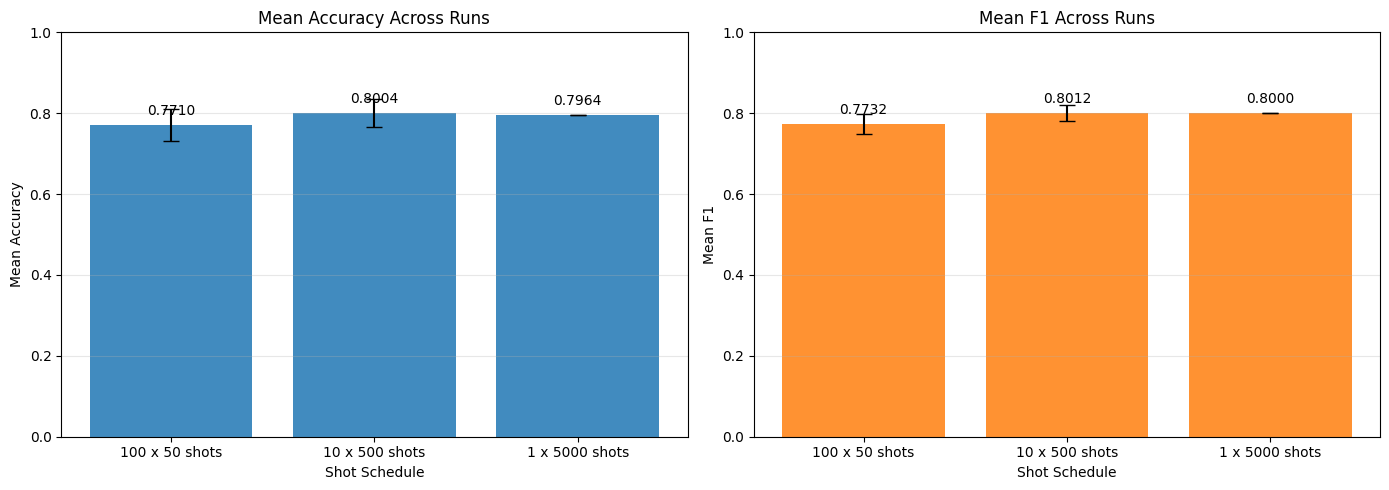

In [3]:
if 'summary_df' not in globals() or summary_df.empty:
    print("Run the repeated IQM experiment cell first.")
else:
    plot_df = summary_df.copy()
    x_labels = plot_df["experiment_label"].astype(str).tolist()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    acc_bars = axes[0].bar(
        x_labels,
        plot_df["mean_accuracy"],
        yerr=plot_df["std_accuracy"],
        capsize=6,
        color="tab:blue",
        alpha=0.85,
    )
    axes[0].set_title("Mean Accuracy Across Runs")
    axes[0].set_ylabel("Mean Accuracy")
    axes[0].set_xlabel("Shot Schedule")
    axes[0].set_ylim(0, 1)
    axes[0].grid(axis="y", alpha=0.3)

    f1_bars = axes[1].bar(
        x_labels,
        plot_df["mean_f1"],
        yerr=plot_df["std_f1"],
        capsize=6,
        color="tab:orange",
        alpha=0.85,
    )
    axes[1].set_title("Mean F1 Across Runs")
    axes[1].set_ylabel("Mean F1")
    axes[1].set_xlabel("Shot Schedule")
    axes[1].set_ylim(0, 1)
    axes[1].grid(axis="y", alpha=0.3)

    for bar in acc_bars:
        height = bar.get_height()
        axes[0].annotate(
            f"{height:.4f}",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 5),
            textcoords="offset points",
            ha="center",
            va="bottom",
        )

    for bar in f1_bars:
        height = bar.get_height()
        axes[1].annotate(
            f"{height:.4f}",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 5),
            textcoords="offset points",
            ha="center",
            va="bottom",
        )

    plt.tight_layout()
    plt.show()
